# Exploratory Data Analysis — SCAPS-1D Solar Cell Dataset

Lightweight EDA only: load the dataset, verify integrity (schema,
full-factorial completeness, PCE identity, physicality), and look at
marginal distributions and input-output trends.

No model fitting happens in this notebook. ANOVA, LOLO-CV, GP fitting,
and Bayesian optimization all live in `scripts/` and are run via the
CLI / `make` targets, not here — see the project README.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import seaborn as sns

from solar_gpr.data import (
    DEFAULT_RAW_PATH, INPUT_COLS, OUTPUT_COLS, get_level_grid,
    load_dataset, verify_dataset_integrity,
)
from solar_gpr.plotting import set_paper_style

set_paper_style()
print(f"Loading dataset from: {DEFAULT_RAW_PATH}")

Loading dataset from: /home/claude/solar-cell-gpr-surrogate/data/raw/SOLAR_DATASET.xlsx


## Load + verify dataset integrity

In [2]:
df = load_dataset()
report = verify_dataset_integrity(df)
print(report.summary())
assert report.ok, "Dataset failed integrity checks -- see summary above"
df.head()

rows: 5000
missing values: 0
duplicate rows: 0
duplicate input combos: 0
levels per input: {'HTL thickness (μm)': 5, 'Absorber Thickness (μm)': 8, 'ETL thickness (μm)': 5, 'N_A (1/cm3)': 5, 'N_D (1/cm3)': 5}
full factorial (5000 expected combos): True (5000 distinct combos)
PCE identity max |error|: 1.337e-06
PCE identity mean |error|: 1.080e-06
physicality violations: {'Voc (V)': 0, 'Jsc (mA/cm2)': 0, 'FF (%)': 0, 'PCE (%)': 0}
rows with N_A > N_D: 0
OK: True


,HTL thickness (μm),Absorber Thickness (μm),ETL thickness (μm),N_A (1/cm3),N_D (1/cm3),PCE (%),Voc (V),Jsc (mA/cm2),FF (%),V_MPP (V),J_MPP (mA/cm2)
0,0.12,1.0,0.02,5.000000e+19,6.000000e+20,35.327328,1.245495,33.767184,83.998975,1.107382,31.901673
1,0.12,1.0,0.02,5.000000e+19,1.950000e+21,35.334359,1.245495,33.766933,84.016294,1.107455,31.905910
2,0.12,1.0,0.02,5.000000e+19,3.300000e+21,35.338190,1.245495,33.766868,84.025551,1.107491,31.908323
3,0.12,1.0,0.02,5.000000e+19,4.650000e+21,35.340756,1.245496,33.766834,84.031726,1.107529,31.909559
4,0.12,1.0,0.02,5.000000e+19,6.000000e+21,35.342405,1.245496,33.766813,84.035703,1.107527,31.911092


## Parameter space

Confirms this is a complete full-factorial grid (5 x 8 x 5 x 5 x 5 = 5000),
not a random/Latin Hypercube sample — this is why LOLO-CV (not a random
train/test split) is the appropriate validation scheme downstream.

In [3]:
level_grid = get_level_grid(df)
for col, levels in level_grid.items():
    print(f"{col}: {len(levels)} levels -> {levels}")

HTL thickness (μm): 5 levels -> [0.12 0.13 0.14 0.15 0.16]
Absorber Thickness (μm): 8 levels -> [1.         1.21428571 1.42857143 1.64285714 1.85714286 2.07142857
 2.28571429 2.5       ]
ETL thickness (μm): 5 levels -> [0.02 0.03 0.04 0.05 0.06]
N_A (1/cm3): 5 levels -> [5.000e+19 1.625e+20 2.750e+20 3.875e+20 5.000e+20]
N_D (1/cm3): 5 levels -> [6.00e+20 1.95e+21 3.30e+21 4.65e+21 6.00e+21]


## Marginal distributions of inputs

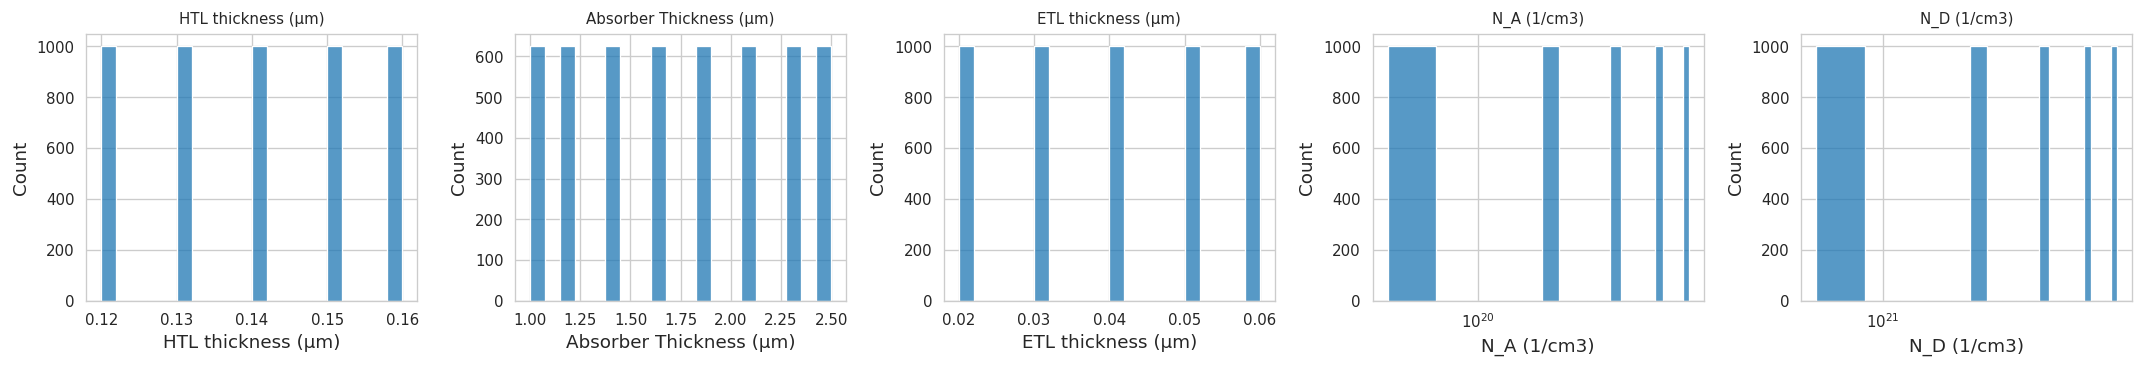

In [4]:
fig, axes = plt.subplots(1, len(INPUT_COLS), figsize=(18, 3.2))
for ax, col in zip(axes, INPUT_COLS):
    sns.histplot(df[col], bins=20, ax=ax, kde=False)
    ax.set_title(col, fontsize=9)
    if col in ("N_A (1/cm3)", "N_D (1/cm3)"):
        ax.set_xscale("log")
fig.tight_layout()
plt.show()

## Marginal distributions of outputs

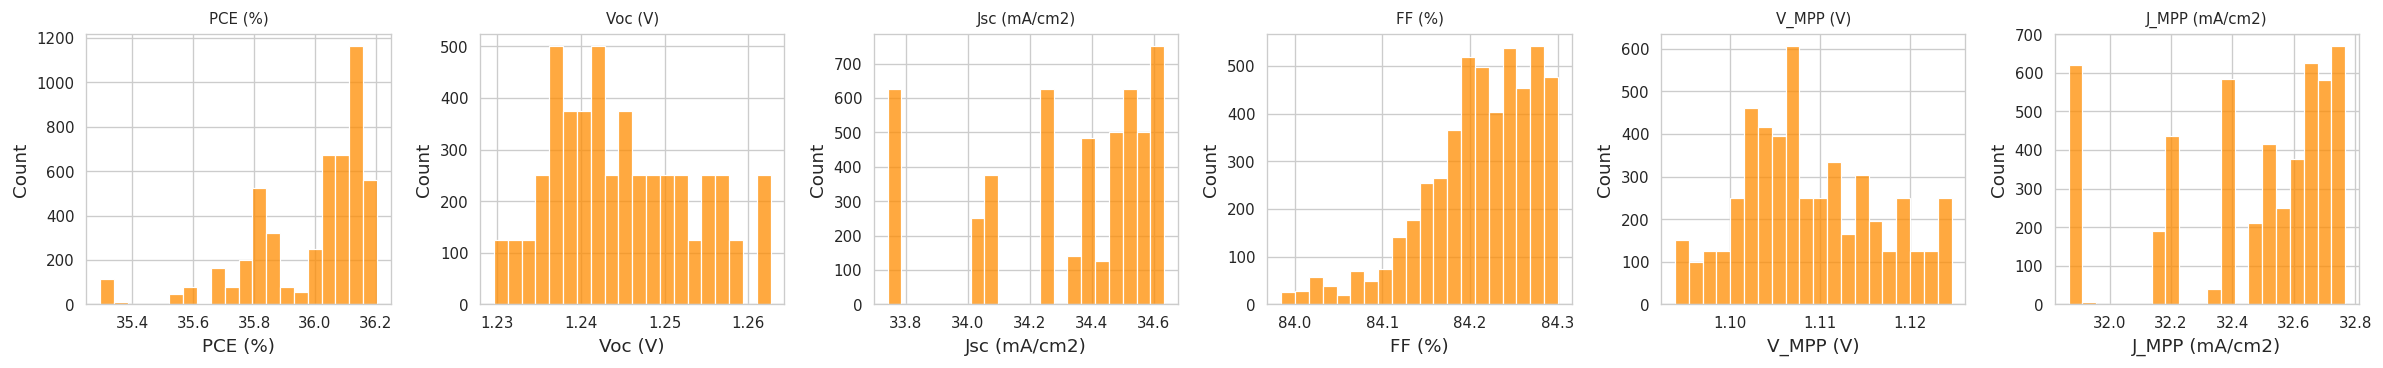

In [5]:
fig, axes = plt.subplots(1, len(OUTPUT_COLS), figsize=(20, 3.2))
for ax, col in zip(axes, OUTPUT_COLS):
    sns.histplot(df[col], bins=20, ax=ax, kde=False, color="darkorange")
    ax.set_title(col, fontsize=9)
fig.tight_layout()
plt.show()

## Input vs. PCE trends

A quick look at each input's marginal relationship with PCE — the
full pairwise (input x sub-metric) grid and the rigorous variance
decomposition live in `scripts/run_anova.py` / `results/figures/`,
not here.

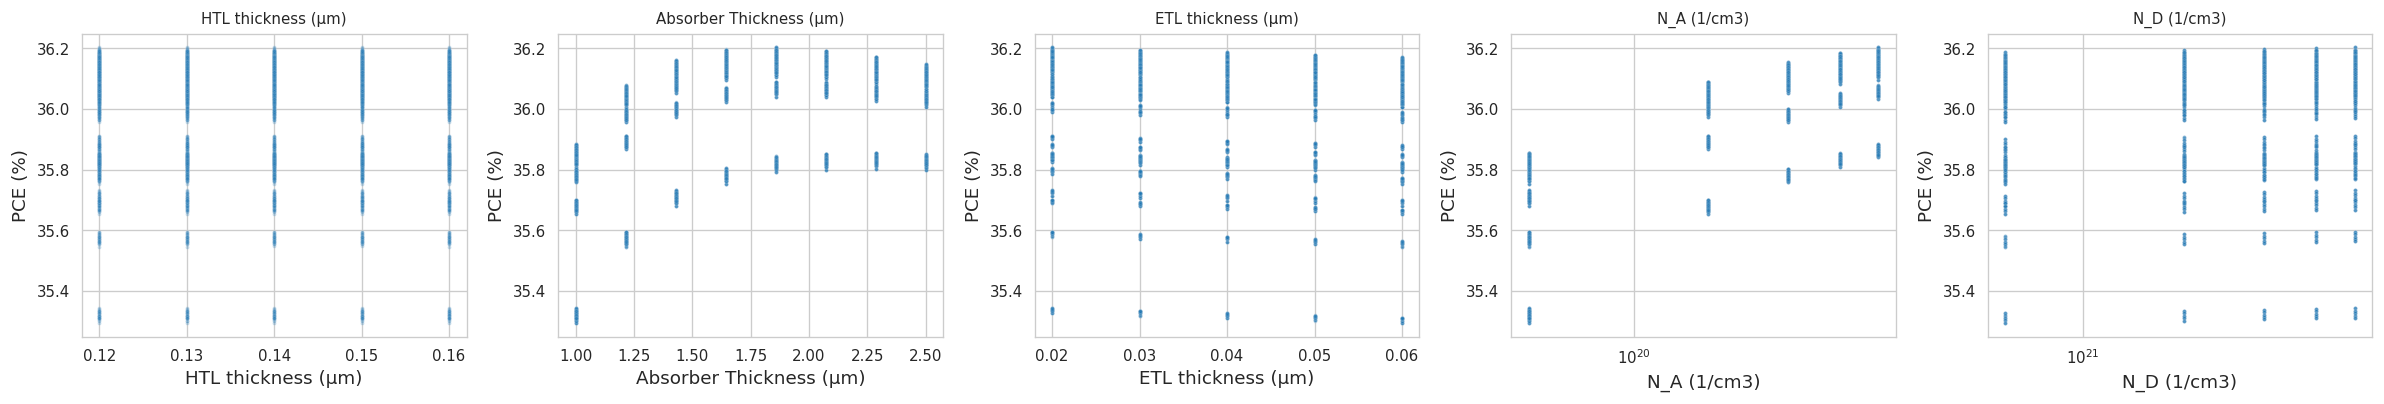

In [6]:
fig, axes = plt.subplots(1, len(INPUT_COLS), figsize=(20, 3.5))
for ax, col in zip(axes, INPUT_COLS):
    sns.scatterplot(data=df, x=col, y="PCE (%)", s=5, alpha=0.25, ax=ax, legend=False)
    ax.set_title(col, fontsize=9)
    if col in ("N_A (1/cm3)", "N_D (1/cm3)"):
        ax.set_xscale("log")
fig.tight_layout()
plt.show()

## Next steps

- `python scripts/run_anova.py` — variance decomposition (eta-squared) per output
- `python scripts/run_lolo_cv.py --n-jobs 4` — kernel comparison (EXPENSIVE)
- `python scripts/run_surrogate_fit.py --kernel <winner>` — fit final GPs (EXPENSIVE)
- `python scripts/run_bo_extrapolation.py` — targeted extrapolation candidates
- `python scripts/make_figures.py` — regenerate all paper figures